### Regional Analysis

In [1]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from scipy.stats import binned_statistic_2d

In [2]:
# Paths and constants
DATA_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/model_outputs"
OUTPUT_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/results"

# Colors
MODEL_COLORS = {
    'ADT-0.25': 'red',
    'ADT-SSS': 'magenta',
    'ADT-SST': 'blue',
    'OSCAR-geos': 'green'
}

In [3]:
# Loading data
os.chdir(DATA_DIR)
files = {
    'ADT-0.25': 'ADT-0.25_interpolated.parquet',
    'ADT-SSS': 'ADT-SSS_interpolated.parquet',
    'ADT-SST': 'ADT-SST_interpolated.parquet',
    'OSCAR-geos': 'OSCAR-geos_interpolated.parquet'
}

all_data = []
for name, path in files.items():
    df = pd.read_parquet(path)
    df = df.rename(columns={'vn': 'v_obs', 've': 'u_obs'})
    df['model_name'] = name
    
    # Calculate scalar speeds and errors
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)
    df['err_speed'] = df['speed_model'] - df['speed_obs']
    df['err_u'] = df['u_model'] - df['u_obs']
    df['err_v'] = df['v_model'] - df['v_obs']
    df['rmse_speed']  = np.abs(df['err_speed'])  
    
    all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)
master_df['model_name'] = master_df['model_name'].astype('category')
master_df['id_sector'] = master_df['id_sector'].astype('category')

In [4]:
# Regional Metrics Calculation
def get_regional_metrics(x):
    """Computes RMSE, Bias, and Correlation for each sector group."""
    stats = {}
    pairs = {
        'Speed': ('speed_model', 'speed_obs', 'err_speed'),
        'U': ('u_model', 'u_obs', 'err_u'),
        'V': ('v_model', 'v_obs', 'err_v')
    }
    
    for label, (mod, obs, err) in pairs.items():
        stats[f'RMSE_{label}'] = np.sqrt(np.mean(x[err]**2))
        stats[f'Bias_{label}'] = np.mean(x[err])
        stats[f'Corr_{label}'] = x[obs].corr(x[mod])
    return pd.Series(stats)

# Grouping by Model and Sector
regional_stats = (
    master_df.groupby(['model_name', 'id_sector'], observed=True)
    .apply(get_regional_metrics, include_groups=False)
    .reset_index()
)

In [5]:
def plot_regional_heatmap(df, metrics, titles, output_path):
    """Heatmap of metrics: rows=sectors, columns=models."""
    models = list(MODEL_COLORS.keys())
    sectors = sorted(df['id_sector'].unique())

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 8))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric, title in zip(axes, metrics, titles):
        # Build matrix: sectors x models
        matrix = pd.DataFrame(index=sectors, columns=models, dtype=float)
        for model in models:
            subset = df[df['model_name'] == model].set_index('id_sector')
            matrix[model] = subset.reindex(sectors)[metric]

        is_bias = 'Bias' in metric
        is_corr = 'Corr' in metric

        if is_bias:
            limit = np.nanmax(np.abs(matrix.values))
            norm = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
            cmap = 'RdBu_r'
        elif is_corr:
            norm = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
            cmap = 'RdYlGn'
        else:
            norm = None
            cmap = 'YlOrRd'

        im = ax.imshow(matrix.values.astype(float), cmap=cmap, norm=norm, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
        ax.set_yticks(range(len(sectors)))
        ax.set_yticklabels(sectors, fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')

        # Annotate cells
        for i in range(len(sectors)):
            for j in range(len(models)):
                val = matrix.iloc[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                            color='black' if abs(val) < 0.7 * np.nanmax(np.abs(matrix.values)) else 'white')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

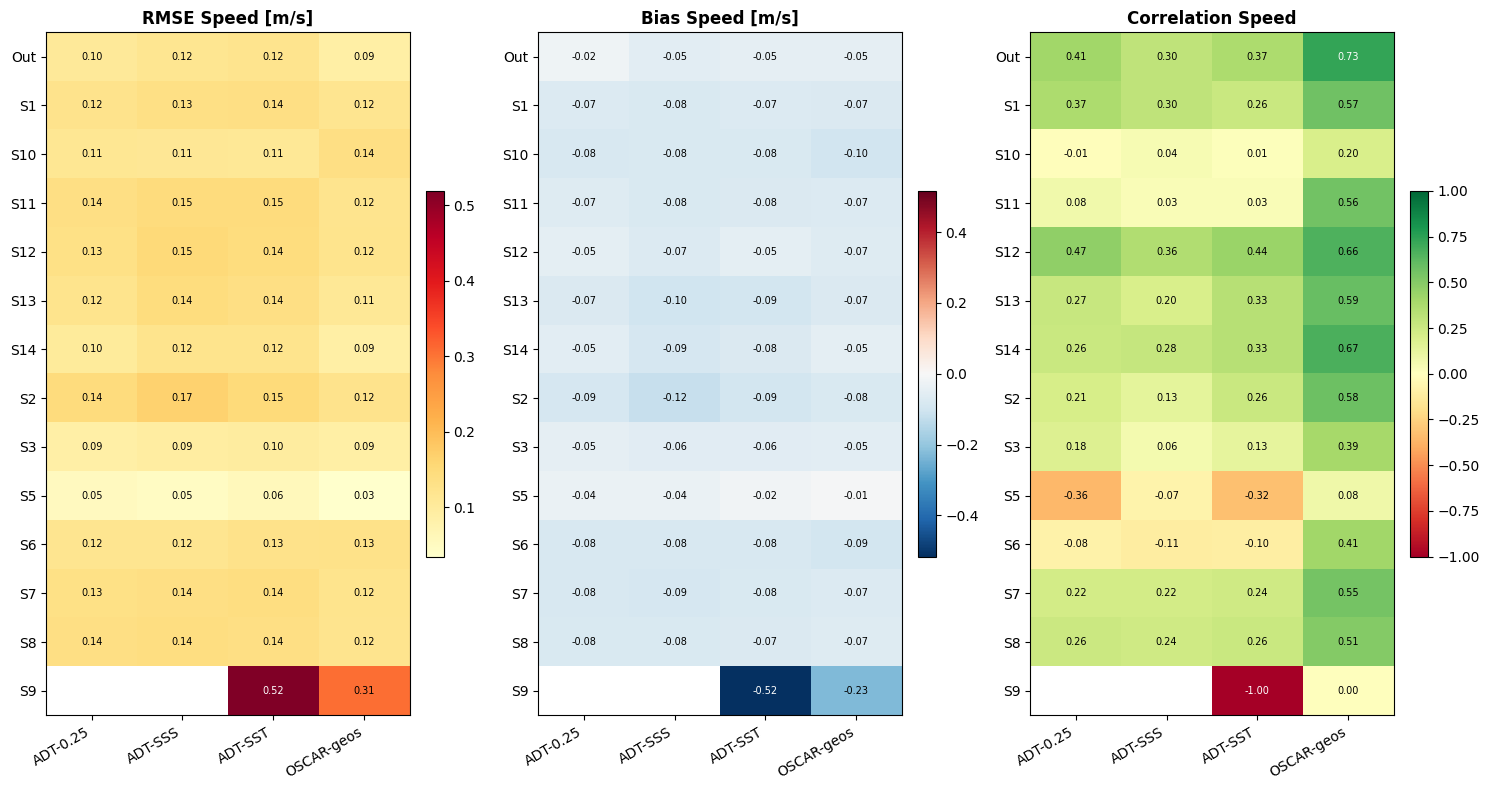

In [6]:
plot_regional_heatmap(
    regional_stats,
    metrics=['RMSE_Speed', 'Bias_Speed', 'Corr_Speed'],
    titles=['RMSE Speed [m/s]', 'Bias Speed [m/s]', 'Correlation Speed'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_speed_heatmap.png')
)

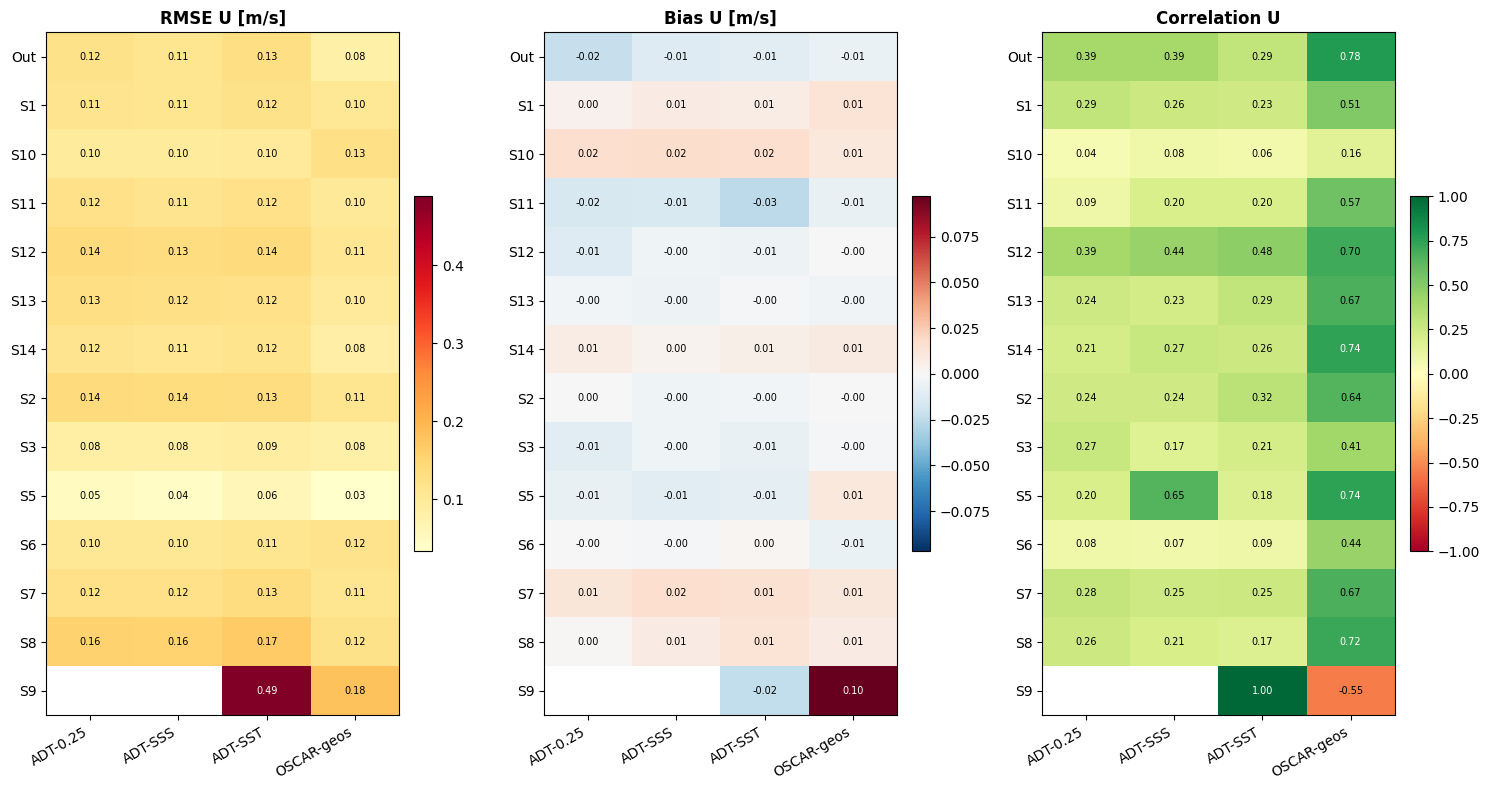

In [7]:
plot_regional_heatmap(
    regional_stats,
    metrics=['RMSE_U', 'Bias_U', 'Corr_U'],
    titles=['RMSE U [m/s]', 'Bias U [m/s]', 'Correlation U'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_u_heatmap.png')
)

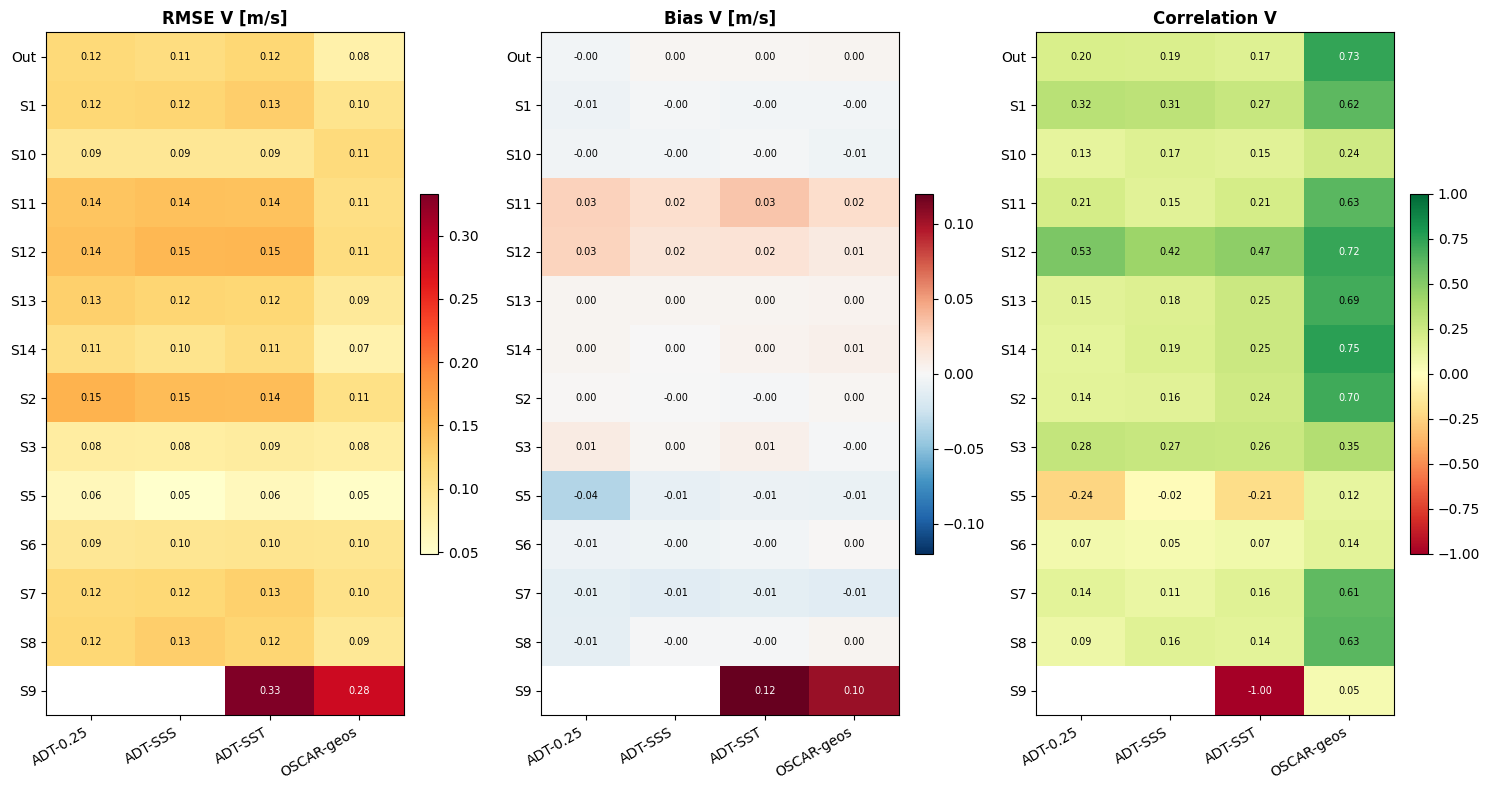

In [8]:
plot_regional_heatmap(
    regional_stats,
    metrics=['RMSE_V', 'Bias_V', 'Corr_V'],
    titles=['RMSE V [m/s]', 'Bias V [m/s]', 'Correlation V'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_v_heatmap.png')
)

In [9]:
# Pre-compute spatial metrics binned on a 2° grid for all models
def compute_spatial_metrics(df, grid_res=2.0):
    """
    Returns a DataFrame with bias, rmse and corr
    for speed, u and v — per (model, grid cell).
    """
    lon_bins    = np.arange(-180, 180 + grid_res, grid_res)
    lat_bins    = np.arange(50,   90  + grid_res, grid_res)
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

    variables = {
        'speed': ('err_speed', 'speed_obs', 'speed_model'),
        'u':     ('err_u',     'u_obs',     'u_model'),
        'v':     ('err_v',     'v_obs',     'v_model'),
    }

    records = []
    for model in df['model_name'].unique():
        sub = df[df['model_name'] == model].dropna(
            subset=['latitude', 'longitude', 'err_speed', 'err_u', 'err_v']
        ).copy()
        sub['lon_bin'] = np.searchsorted(lon_bins, sub['longitude'], side='right') - 1
        sub['lat_bin'] = np.searchsorted(lat_bins, sub['latitude'],  side='right') - 1

        # Bias and RMSE via binned_statistic_2d
        grids = {}
        for var, (err_col, obs_col, mod_col) in variables.items():
            bias_g, _, _, _ = binned_statistic_2d(
                sub['longitude'], sub['latitude'], sub[err_col],
                statistic='mean', bins=[lon_bins, lat_bins]
            )
            rmse_g, _, _, _ = binned_statistic_2d(
                sub['longitude'], sub['latitude'], sub[err_col],
                statistic=lambda x: np.sqrt(np.mean(x**2)),
                bins=[lon_bins, lat_bins]
            )
            corr_g = np.full((len(lon_centers), len(lat_centers)), np.nan)
            for (li, lj), g in sub.groupby(['lon_bin', 'lat_bin'], observed=True):
                if 0 <= li < len(lon_centers) and 0 <= lj < len(lat_centers) and len(g) >= 3:
                    corr_g[li, lj] = g[obs_col].corr(g[mod_col])
            grids[var] = (bias_g, rmse_g, corr_g)

        for i, lon_c in enumerate(lon_centers):
            for j, lat_c in enumerate(lat_centers):
                row = {'model_name': model, 'lon_center': lon_c, 'lat_center': lat_c}
                for var, (bias_g, rmse_g, corr_g) in grids.items():
                    row[f'bias_{var}'] = bias_g[i, j]
                    row[f'rmse_{var}'] = rmse_g[i, j]
                    row[f'corr_{var}'] = corr_g[i, j]
                # Only keep cells that have at least one non-NaN value
                if any(not np.isnan(v) for k, v in row.items() if k != 'model_name'):
                    records.append(row)

    return pd.DataFrame(records)

spatial_metrics = compute_spatial_metrics(master_df)
print(spatial_metrics.columns.tolist())
print(spatial_metrics.shape)

['model_name', 'lon_center', 'lat_center', 'bias_speed', 'rmse_speed', 'corr_speed', 'bias_u', 'rmse_u', 'corr_u', 'bias_v', 'rmse_v', 'corr_v']
(14400, 12)


In [13]:
def plot_spatial_arctic_error_refined(spatial_df, model_name, metric='bias_speed', output_path=None):
    """
    Plots Arctic spatial metrics from spatial_metrics.
    metric examples: 'bias_speed', 'rmse_speed', 'corr_speed',
                     'bias_u', 'rmse_u', 'corr_u',
                     'bias_v', 'rmse_v', 'corr_v'
    """
    subset = spatial_df[
        (spatial_df['model_name'] == model_name) &
        spatial_df[metric].notna()
    ]

    if 'bias' in metric:
        cmap  = 'RdBu_r'
        limit = subset[metric].abs().max()
        norm  = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
        label = f'Bias {metric.split("_")[1].upper()} — {model_name} [m/s]'
    elif 'corr' in metric:
        cmap  = 'RdYlGn'
        norm  = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
        label = f'Correlation {metric.split("_")[1].upper()} — {model_name}'
    else:
        cmap = 'YlOrRd'
        rmse_max = spatial_df[metric].max(skipna=True)
        vmax = rmse_max if pd.notna(rmse_max) and rmse_max > 0 else 1.0
        norm = plt.Normalize(vmin=0, vmax=vmax)
        label = f'RMSE {metric.split("_")[1].upper()} — {model_name} [m/s]'

    # Figure setup
    fig = plt.figure(figsize=(10, 10))
    ax  = plt.axes(projection=ccrs.NorthPolarStereo())
    ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())

    theta  = np.linspace(0, 2 * np.pi, 100)
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)

    sc = ax.scatter(
        subset['lon_center'], subset['lat_center'],
        c=subset[metric], cmap=cmap, norm=norm,
        s=60, transform=ccrs.PlateCarree(),
        zorder=1, edgecolors='none', alpha=0.85
    )

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=10)
    ax.coastlines(resolution='50m', color='black', linewidth=0.7, zorder=11)
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.3, zorder=20)
    gl.top_labels   = False
    gl.right_labels = False

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical',
                        pad=0.05, fraction=0.035, shrink=0.7)
    cbar.set_label(label, fontsize=12)

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

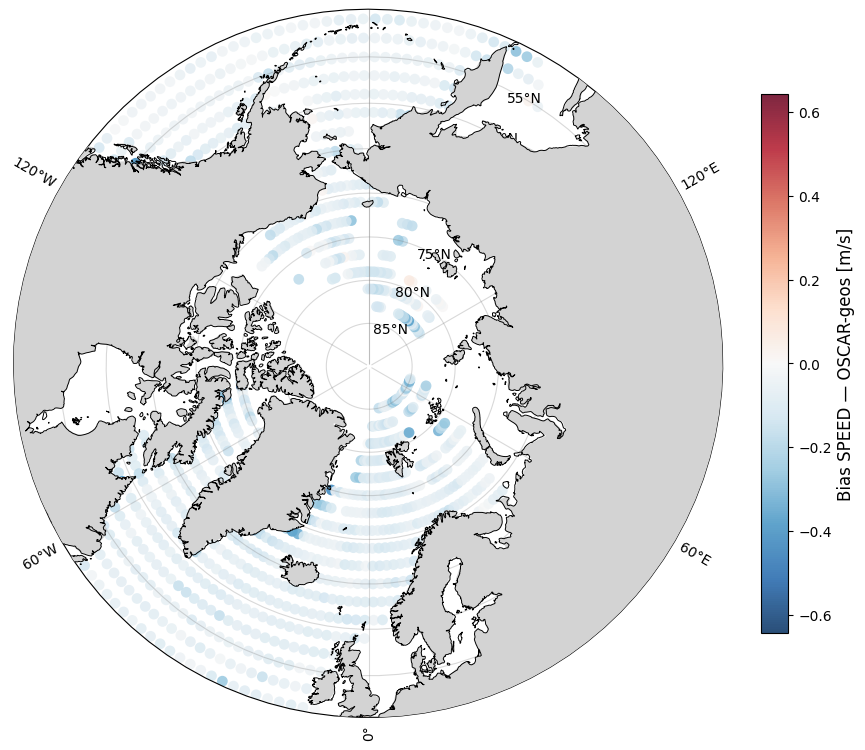

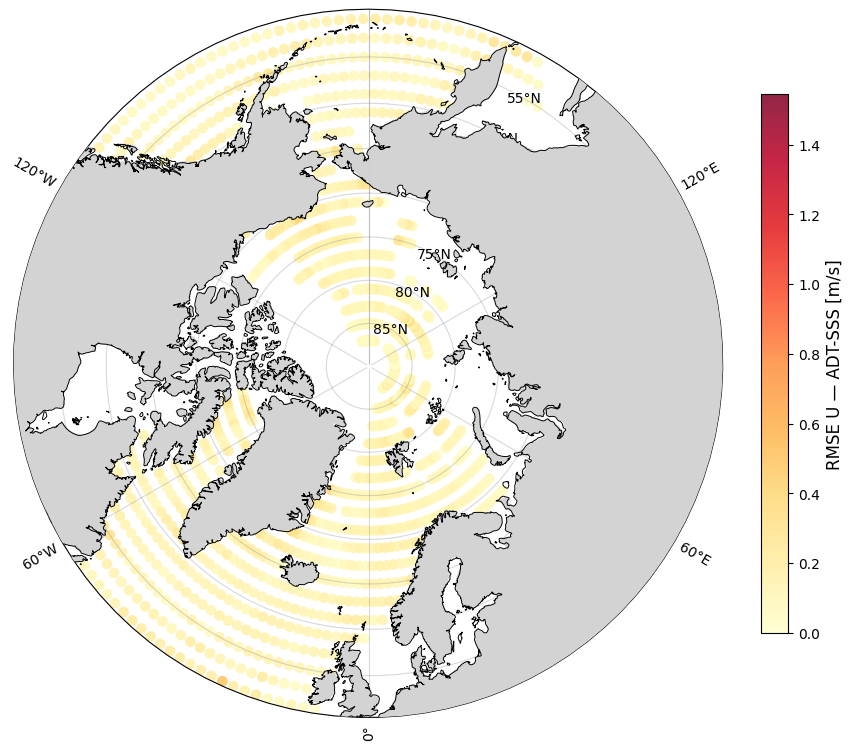

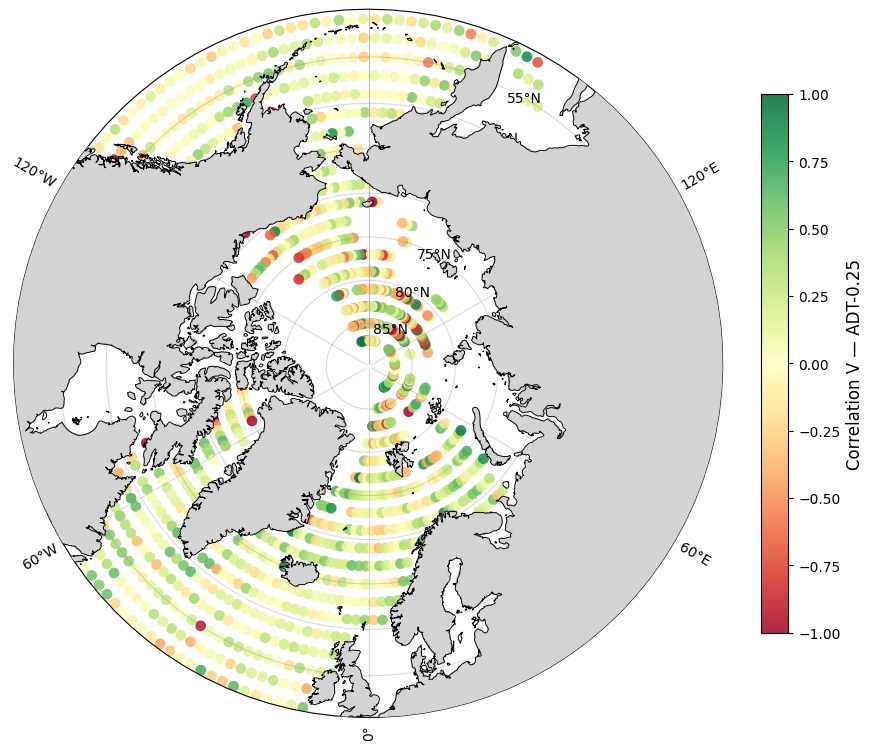

In [14]:
# Examples
plot_spatial_arctic_error_refined(spatial_metrics, 'OSCAR-geos', metric='bias_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_bias_speed_oscar_geos.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'ADT-SSS', metric='rmse_u',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_u_adt_sss.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'ADT-0.25', metric='corr_v',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_corr_v_adt025.png'))

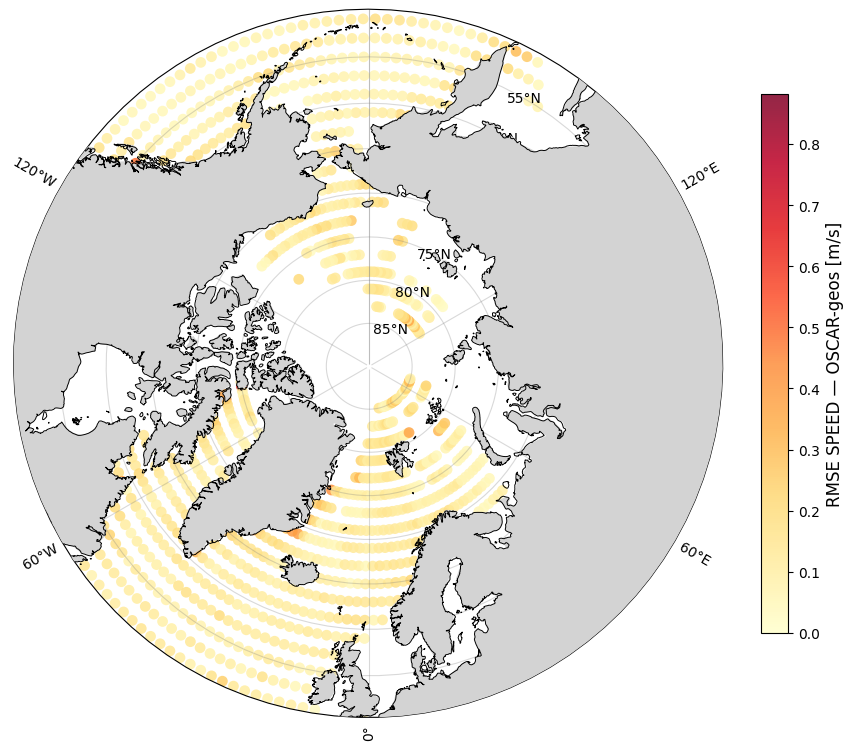

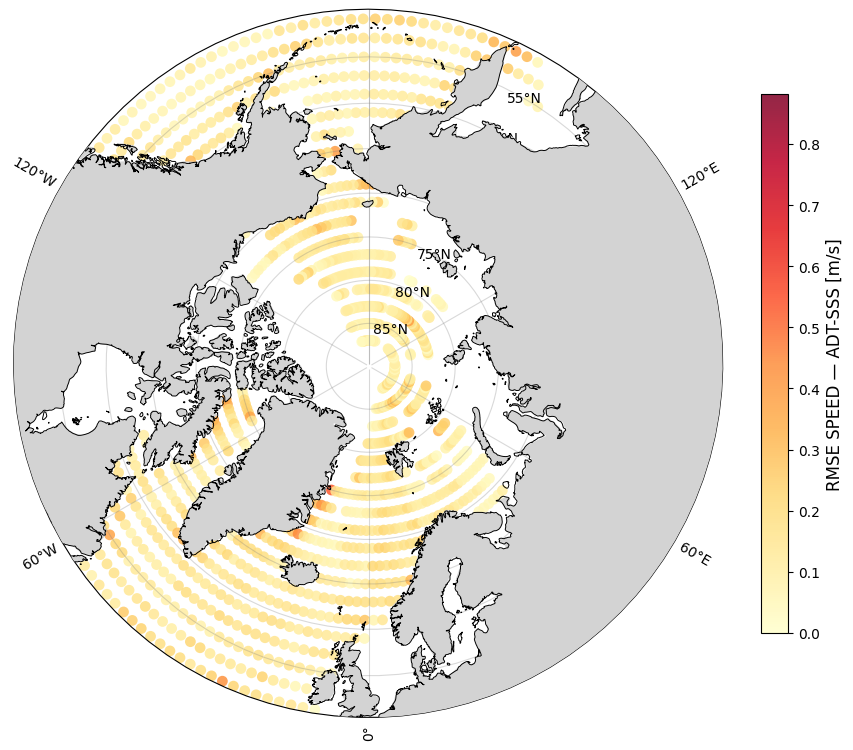

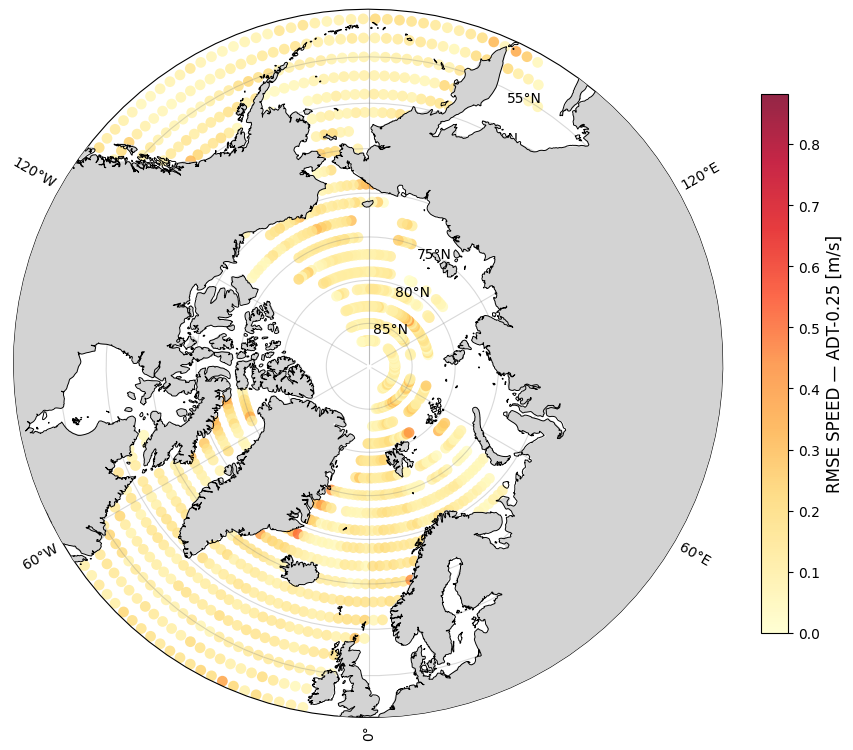

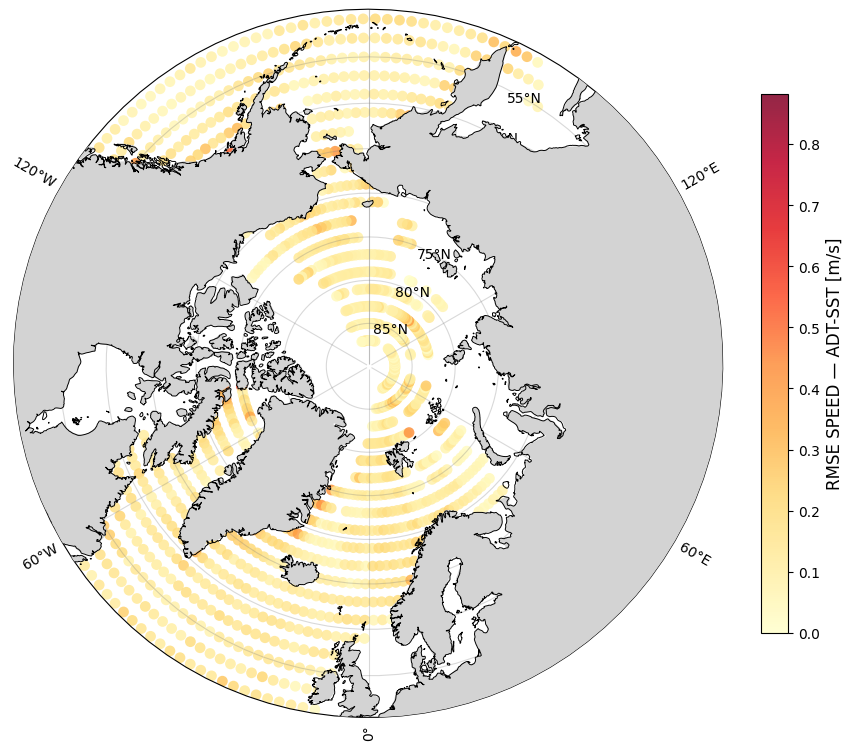

In [15]:
# Examples
plot_spatial_arctic_error_refined(spatial_metrics, 'OSCAR-geos', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_oscar_geos.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'ADT-SSS', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_adt_sss.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'ADT-0.25', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_adt025.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'ADT-SST', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_adt_sst.png'))